# Ejercicio Deber Análisis de datos clínicos para la detección de enfermedades cardíacas
## Nombre: Steven Chuiza
### Fecha: 05/05/2026

# Práctica Académica
## Normalización y Estandarización de Datos en Inteligencia Artificial
# Análisis y aplicación de técnicas de normalización y estandarización en conjunto de datos para modelos de aprendizaje automático
### Enunciado
En la actualidad, las enfermedades cardiovasculares representan una de las principales causas de mortalidad a nivel mundial, lo que ha impulsado el uso de técnicas de análisis de datos e inteligencia artificial para apoyar en su detección temprana.<br>

Un centro médico especializado ha recopilado un conjunto de datos clínicos de pacientes, el cual incluye variables como edad, presión arterial, niveles de colesterol, frecuencia cardíaca máxima y otros indicadores relevantes para la salud cardiovascular. Sin embargo, durante el análisis preliminar, se ha identificado que los datos presentan diferencias significativas en sus escalas y rangos, lo que podría afectar negativamente el desempeño de los modelos predictivos.<br>

Como parte del equipo de analistas de datos, se le ha asignado la tarea de realizar un proceso de preprocesamiento de los datos, específicamente aplicando técnicas de normalización y estandarización, con el objetivo de preparar la información para su uso en modelos de aprendizaje automático orientados a la clasificación de pacientes con riesgo de enfermedad cardíaca.<br>
El propósito de esta actividad es comprender cómo las diferencias en la escala de los datos pueden influir en los resultados y cómo las técnicas de escalado permiten mejorar la calidad del análisis y la precisión de los modelos.<br>
### Objetivo General
Aplicar técnicas de normalización y estandarización a un conjunto de datos clínicos relacionados con enfermedades cardíacas, con el fin de analizar su impacto en la preparación de datos y en el rendimiento de modelos de aprendizaje automático.<br>
### Objetivos especificos
* Identificar diferencias de escala entre variables numércias.
* Aplicar técnicas de normalización (Min-Max)
* Aplicar técnicas de estandarización (Z-score)
* Analizar la importancia del preprocesaminto en modelos de IA
### Antecedentes /Fundamentación teórica
En el contexto del aprendizaje automático, los algoritmos suelen verse afectados por la escala de los datos. Variables con valores grandes pueden dominar el comportamiento del modelo, generando sesgos y resultados pocos conficables.<br>
Para mitigar este problema, se emplea técnicas como:
* **Normalización**: transforma los datos a un rango especifico (generalmente[0,1])
* **Estandarización**: ajusta los datos para que tengan mdia 0 y desviación estandar 1.
Estas técnicas son fundamentales en algoritmos como:
* KNN
* Regresión logística
* Redes neuronales
### Resultado esperado
El estudiante será capaz de reconocer la importancia del escalado de datos en contextos reales de salud, comprendiendo que un adecuado preprocesamiento es fundamental para el desarrollo de modelos predictivos confiables en inteligencia artificial.
## Conjunto de datos  utilizar
DataSet 1: <a href="https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset">Conjunto de datos de enfermedades cardiacas</a>

In [1]:
#Importacion de librerias 
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
import zipfile
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing

In [2]:
#Configuramos el entorno de descarga
import os
os.environ['KAGGLE_CONFIG_DIR'] = r"C:\Users\alexa\.kaggle"

In [4]:
# Descargar el dataset de enfermedades cardiacas
!kaggle datasets download -d johnsmith88/heart-disease-dataset

Dataset URL: https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset
License(s): unknown




  0%|          | 0.00/6.18k [00:00<?, ?B/s]
100%|##########| 6.18k/6.18k [00:00<00:00, 4.10MB/s]


In [5]:
#Descompriminos el data set de enfermedades cardiacas 
with zipfile.ZipFile('heart-disease-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('dataset') # Esto lo guardará en la carpeta 'dataset'

print("¡Archivo descomprimido con éxito!")

¡Archivo descomprimido con éxito!


In [7]:
# Cargar el dataset de enfermedades cardiacas ya descomprimido
df = pd.read_csv('dataset/heart.csv')

In [8]:
# Mostrar las primeras filas
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [9]:
#Eliminamos columnas innecesarias en la limpieza de datos como vemos en el dataframe la columna id no aporta
#nada a nuestro modelo por lo tanto lo eliminamos 
if 'Id' in df.columns:
    df=df.drop(columns=["Id"])

In [10]:
#Mostramos los detalles de nuesto dataset
df.info()
#Vrificamos si tenemos datos nulos si lo tenemos lo sumamos 
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [11]:
# 'X' son las características (features), eliminamos la columna objetivo
X = df.drop('target', axis=1)

# 'y' es nuestra variable objetivo
y = df['target']

In [12]:
#Exploramos o generamos un analis exploratorio del conjutno de datos
X.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000


### Conclusion

Al observar la tabla de datos y comparar las variables clínicas, se hace evidente que cada una se mide en unidades y rangos drásticamente diferentes:

* Colesterol (chol): Presenta valores que pueden superar los 500 mg/dl, con una variación muy amplia (rango de más de 400 unidades).

* Antigüedad de la depresión del ST (oldpeak): Por el contrario, tiene valores mucho más pequeños, moviéndose mayoritariamente en un rango de 0.0 a 6.2.

* Presión Arterial (trestbps): Se sitúa en un punto intermedio, con valores que oscilan generalmente entre 94 y 200 mm Hg.

### ¿Qué significa esto para nuestro programa?
Esta disparidad confirma que las variables no están en la misma escala. Si entrenáramos un modelo de Machine Learning sin preprocesar estos datos, el algoritmo podría darle una importancia injustificada a la variable chol solo porque sus números son más grandes, ignorando factores críticos como oldpeak. Por lo tanto, es indispensable aplicar Estandarización o Normalización para que todas las variables contribuyan de manera equitativa al diagnóstico final.

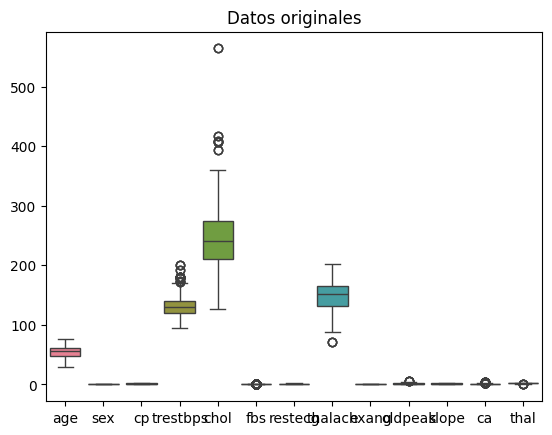

In [13]:
#dibujamso los datos originales 
sns.boxplot(data=X)
#Ponemos un titulo a la imagen 
plt.title("Datos originales")
plt.show()

## Interpretación del Gráfico: Datos Originales
Al visualizar la distribución de todas las variables del dataset de enfermedades cardiacas en un mismo gráfico, podemos extraer las siguientes conclusiones críticas:

1. Diferencia Extrema de Escalas:

* Se observa que la variable chol (colesterol) domina completamente el gráfico. Sus valores alcanzan casi los 600, mientras que variables como oldpeak o target son prácticamente invisibles en la parte inferior porque sus valores son cercanos a cero.

* Esto confirma visualmente que los datos "no hablan el mismo idioma" en términos de magnitud.

2. Presencia de Outliers (Valores Atípicos):

* Los puntos negros por encima de las cajas en chol, trestbps (presión arterial) y thalach indican la presencia de pacientes con niveles excepcionalmente altos.

* Especialmente en el colesterol, vemos un valor que se dispara casi hasta 600, lo cual podría sesgar el entrenamiento del modelo si no se trata adecuadamente.

3. Variabilidad Dispar:

* La "caja" de chol es mucho más alta que las demás, lo que significa que hay mucha más dispersión en los niveles de colesterol de los pacientes que en su edad o su presión arterial en reposo.

In [14]:
#Normalizamos el conjunto de datos 
normalizer = preprocessing.MinMaxScaler()
X_norm=normalizer.fit_transform(X)
X_norm = pd.DataFrame(X_norm, columns=X.columns)
X_norm.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,0.479167,1.0,0.0,0.292453,0.196347,0.0,0.5,0.740458,0.0,0.161290,1.0,0.50,1.000000
1,0.500000,1.0,0.0,0.433962,0.175799,1.0,0.0,0.641221,1.0,0.500000,0.0,0.00,1.000000
2,0.854167,1.0,0.0,0.481132,0.109589,0.0,0.5,0.412214,1.0,0.419355,0.0,0.00,1.000000
3,0.666667,1.0,0.0,0.509434,0.175799,0.0,0.5,0.687023,0.0,0.000000,1.0,0.25,1.000000
4,0.687500,0.0,0.0,0.415094,0.383562,1.0,0.5,0.267176,0.0,0.306452,0.5,0.75,0.666667


In [15]:
X_norm.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,0.529878,0.695610,0.314146,0.354827,0.273973,0.149268,0.264878,0.596291,0.336585,0.172825,0.692683,0.188537,0.774634
std,0.189006,0.460373,0.343214,0.165252,0.117791,0.356527,0.263939,0.175616,0.472772,0.189525,0.308878,0.257699,0.206887
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.395833,0.000000,0.000000,0.245283,0.194064,0.000000,0.000000,0.465649,0.000000,0.000000,0.500000,0.000000,0.666667
50%,0.562500,1.000000,0.333333,0.339623,0.260274,0.000000,0.500000,0.618321,0.000000,0.129032,0.500000,0.000000,0.666667
75%,0.666667,1.000000,0.666667,0.433962,0.340183,0.000000,0.500000,0.725191,1.000000,0.290323,1.000000,0.250000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [16]:
#Estaddarización 
standarizer = preprocessing.StandardScaler()
#Estandarizamos los datos
X_std=standarizer.fit_transform(X)
X_std= pd.DataFrame(X_std, columns=X.columns)
X_std.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,-0.268437,0.661504,-0.915755,-0.377636,-0.659332,-0.418878,0.891255,0.821321,-0.712287,-0.060888,0.995433,1.209221,1.089852
1,-0.158157,0.661504,-0.915755,0.479107,-0.833861,2.387330,-1.004049,0.255968,1.403928,1.727137,-2.243675,-0.731971,1.089852
2,1.716595,0.661504,-0.915755,0.764688,-1.396233,-0.418878,0.891255,-1.048692,1.403928,1.301417,-2.243675,-0.731971,1.089852
3,0.724079,0.661504,-0.915755,0.936037,-0.833861,-0.418878,0.891255,0.516900,-0.712287,-0.912329,0.995433,0.238625,1.089852
4,0.834359,-1.511706,-0.915755,0.364875,0.930822,2.387330,0.891255,-1.874977,-0.712287,0.705408,-0.624121,2.179817,-0.522122


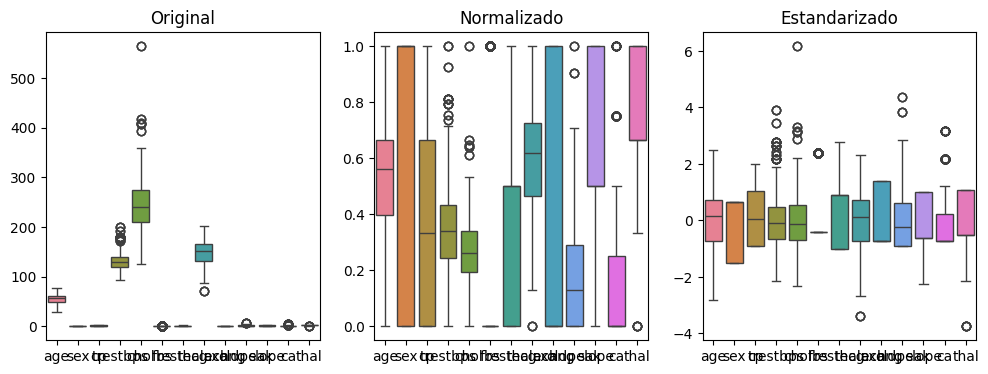

In [17]:
#Comporación visual
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.boxplot(data=X)
plt.title("Original")

plt.subplot(1,3,2)
sns.boxplot(data=X_norm)
plt.title("Normalizado")

plt.subplot(1,3,3)
sns.boxplot(data=X_std)
plt.title("Estandarizado")

plt.show()

Repositorio de GitHub:https://github.com/tiven29/Fundamentos_Machine_Learning/tree/main/.ipynb_checkpoints